In [1]:
import os 
import glob

curfolder = os.getcwd()
datafolder = os.path.join(curfolder, 'projectdata')

tposetotrack = glob.glob(os.path.join(datafolder, '*', '*tpose*', 'kinematics', '*smoothed.sto'), recursive=True)

# get rid of 35_1_tpose files, 8_1_tpose, 36_1_tpose_p0 and 43_1_tpose_p0
tposetotrack = [f for f in tposetotrack if '35_1_tpose' not in f and '8_1_tpose' not in f and '36_1_tpose_p0' not in f and '43_1_tpose_p0' not in f]

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

def overlay_trials(files, column, alpha=0.2):
    plt.figure(figsize=(10, 4))

    for file in files:
        #df = pd.read_csv(file, usecols=[column])
        df = pd.read_csv(file, sep='\t', skiprows=6, usecols=[column])
        plt.plot(df[column].values, alpha=alpha, linewidth=1)

    plt.title(f"Overlay of {column} across trials")
    plt.xlabel("Time (samples)")
    plt.ylabel(column)
    plt.show()


In [27]:
import plotly.graph_objects as go

def overlay_trials_plotly(files, column):
    fig = go.Figure()


    for file in files:

        filename = os.path.basename(file)
        # get rid of the tpose in the name
        filename = filename.replace('_tpose', '')
        df = pd.read_csv(
            file,
            sep="\t",
            skiprows=6,
            usecols=[column]
        )
        fig.add_trace(
            go.Scatter(
                y=df[column].values,
                mode="lines",
                name=filename,
                opacity=0.3,
                showlegend=False
            )
        )

    fig.update_layout(
        title=f"Overlay of {column} across trials",
        xaxis_title="Time (samples)",
        yaxis_title=column
    )

    fig.show()


In [28]:
columns_to_plot = ['wrist_flex_r_moment', 'elbow_flex_r_moment', 'arm_flex_r_moment', 'ankle_angle_r_moment', 'knee_angle_r_moment']

for col in columns_to_plot:
    overlay_trials_plotly(tposetotrack, col)

In [40]:
columns_to_plot = ['wrist_flex_r_moment', 'elbow_flex_r_moment', 'arm_flex_r_moment', 'ankle_angle_r_moment', 'knee_angle_r_moment']

import pandas as pd
import os

def compute_means_per_file(files, columns):
    rows = []

    for file in files:
        df = pd.read_csv(
            file,
            sep="\t",
            skiprows=6,
            usecols=columns
        )

        means = df.mean()  # mean per column
        sd = df.std()    # standard deviation per column

        row = {
            "file": os.path.basename(file),
        }
        row.update(means.to_dict())
        #row.update(sd.to_dict())
        rows.append(row)

    return pd.DataFrame(rows)


In [41]:
means_df = compute_means_per_file(tposetotrack, columns_to_plot)
means_df.head()


,file,knee_angle_r_moment,ankle_angle_r_moment,arm_flex_r_moment,elbow_flex_r_moment,wrist_flex_r_moment
0,10_1_tpose_p0_0-199_filt_butterworth_processed...,1.079313,1.208972,1.236435,-1.634720,-0.225677
1,10_1_tpose_p1_0-207_filt_butterworth_processed...,1.252039,0.776448,-2.745683,-1.139622,-0.129035
2,11_1_tpose_p0_0-156_filt_butterworth_processed...,0.146150,0.745434,-0.206847,-0.753573,-0.156329
3,11_1_tpose_p1_0-140_filt_butterworth_processed...,0.869646,0.821019,-1.858702,-1.812024,-0.182240
4,12_1_tpose_p0_0-215_filt_butterworth_processed...,0.795436,0.874904,-0.160561,-0.469979,-0.059722


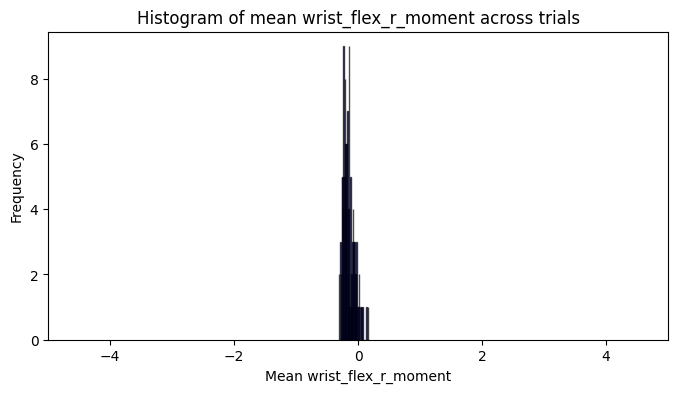

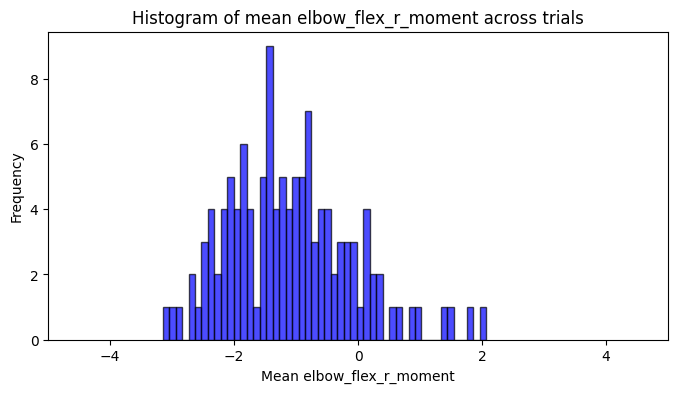

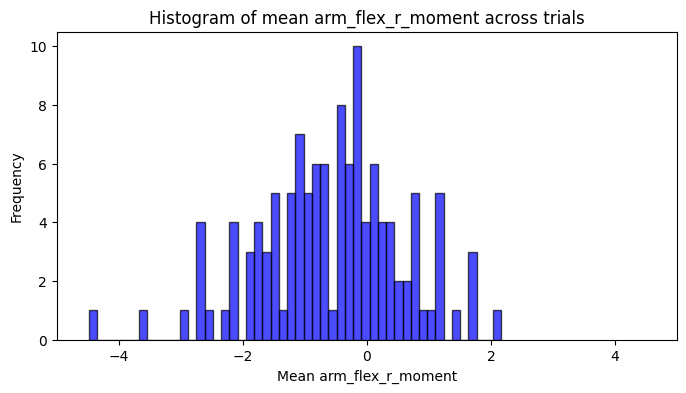

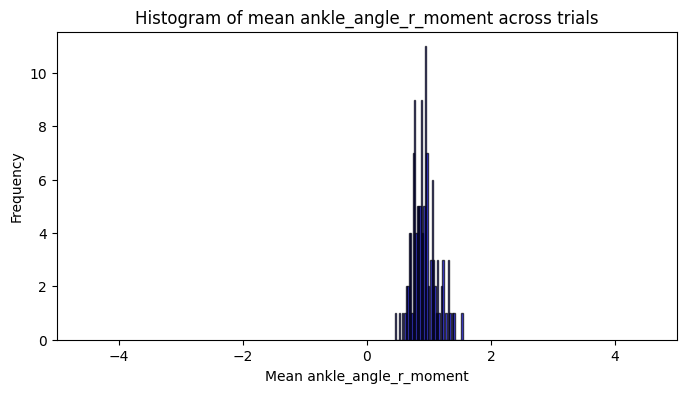

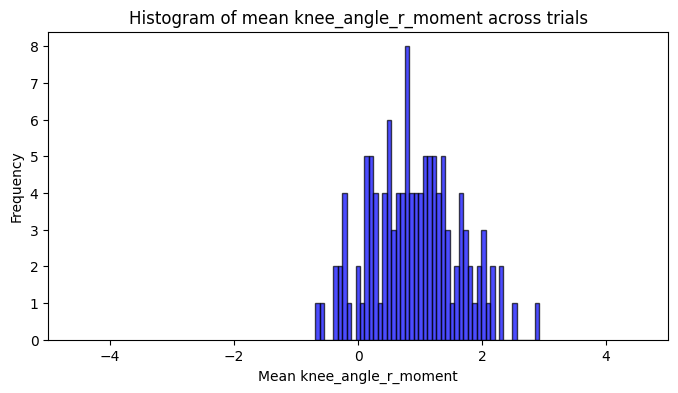

In [47]:
# make histogram of mean

for col in columns_to_plot:
    plt.figure(figsize=(8, 4))
    plt.hist(means_df[col], bins=50, alpha=0.7, color='blue', edgecolor='black')
    plt.title(f"Histogram of mean {col} across trials")
    plt.xlabel(f"Mean {col}")
    # xlim -5 to 5
    plt.xlim(-5, 5)
    plt.ylabel("Frequency")
    plt.show()

In [43]:
columns_to_plot = ['wrist_flex_r_moment', 'elbow_flex_r_moment', 'arm_flex_r_moment', 'ankle_angle_r_moment', 'knee_angle_r_moment']

import pandas as pd
import os

def compute_sd_per_file(files, columns):
    rows = []

    for file in files:
        df = pd.read_csv(
            file,
            sep="\t",
            skiprows=6,
            usecols=columns
        )

        #means = df.mean()  # mean per column
        sd = df.std()    # standard deviation per column

        row = {
            "file": os.path.basename(file),
        }
        #row.update(means.to_dict())
        row.update(sd.to_dict())
        rows.append(row)

    return pd.DataFrame(rows)


In [45]:
sd_df = compute_sd_per_file(tposetotrack, columns_to_plot)
sd_df.head()


,file,knee_angle_r_moment,ankle_angle_r_moment,arm_flex_r_moment,elbow_flex_r_moment,wrist_flex_r_moment
0,10_1_tpose_p0_0-199_filt_butterworth_processed...,0.497299,0.042176,0.259629,0.955073,0.047879
1,10_1_tpose_p1_0-207_filt_butterworth_processed...,0.369792,0.038511,0.443574,0.783406,0.097549
2,11_1_tpose_p0_0-156_filt_butterworth_processed...,0.192425,0.014314,0.649136,1.181342,0.086196
3,11_1_tpose_p1_0-140_filt_butterworth_processed...,0.238958,0.023408,0.227092,0.155555,0.019209
4,12_1_tpose_p0_0-215_filt_butterworth_processed...,0.124401,0.018342,0.172593,0.622010,0.059006


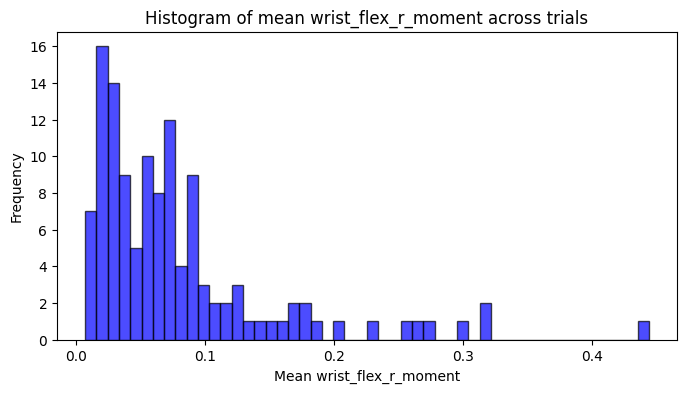

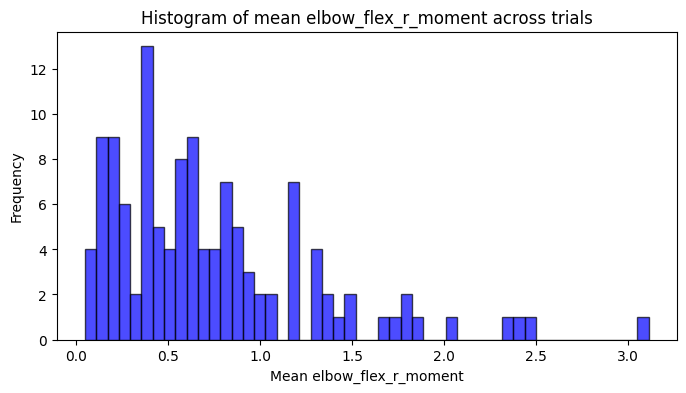

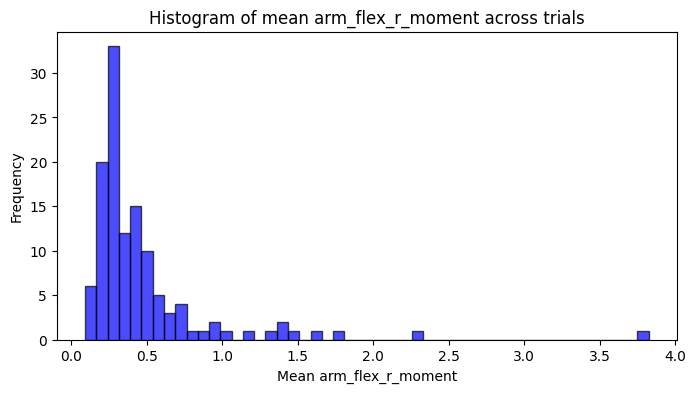

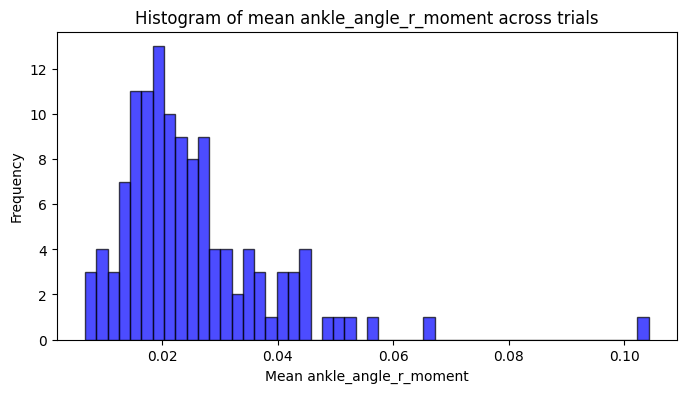

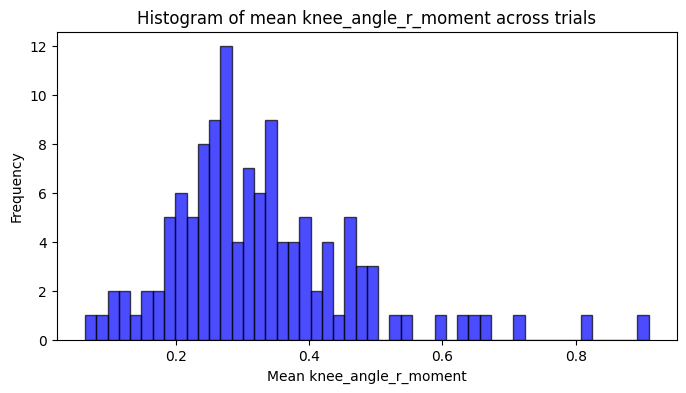

In [ ]:
# make histogram of sd

for col in columns_to_plot:
    plt.figure(figsize=(8, 4))
    plt.hist(sd_df[col], bins=50, alpha=0.7, color='blue', edgecolor='black')
    plt.title(f"Histogram of mean {col} across trials")
    plt.xlabel(f"Mean {col}")
    plt.ylabel("Frequency")
    plt.show()